# 5 - K-Means + Association Rule Mining

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

# Install mlxtend if not present
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'mlxtend', '-q'])
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules

# --- Configuration & Constants ---
DATA_PATH  = 'data/mobile_price.csv'
TARGET_COL = 'price_range'
SEEDS      = [0, 10, 42, 100, 999]
N_CLUSTERS = 4
CLASSES    = [0, 1, 2, 3]

In [2]:
# --- 1. Data Loading & Standardization ---
df = pd.read_csv(DATA_PATH)
FEATURES = [c for c in df.columns if c != TARGET_COL]

X_raw = df[FEATURES].values
y = df[TARGET_COL].values

# Standardization is critical for K-Means distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Initialized dataset with {X_scaled.shape[0]} samples and {len(FEATURES)} features.")

Initialized dataset with 2000 samples and 20 features.


In [3]:
# --- 2. Discretization (3:4:3 Ratio) ---
# Required to convert continuous hardware specs into categories for ARM
def categorize_343(series):
    min_v, max_v = series.min(), series.max()
    rng = max_v - min_v + 1e-9
    out = pd.Series(index=series.index, dtype='object')
    out[series <= min_v + 0.30 * rng]                                    = 'low'
    out[(series > min_v + 0.30 * rng) & (series <= min_v + 0.70 * rng)] = 'medium'
    out[series > min_v + 0.70 * rng]                                     = 'high'
    return out

cat_df = pd.DataFrame(index=df.index)
for col in FEATURES:
    cat_df[col] = categorize_343(df[col])

In [10]:
# ── 3. ARM: Extract Discriminative Class Signatures ───────────────────────────
#
#   For each class c, mine frequent patterns using FP-Growth, generate
#   association rules, and keep the top 20 by lift as the "class signature".
#   High-lift rules = most characteristic co-occurrence patterns of that class.
 
top_rules_per_class = {c: [] for c in CLASSES}
 
print('\nMining discriminative patterns per class...')
for c in CLASSES:
    subset       = cat_df[y == c][FEATURES]
    n_c          = len(subset)
    transactions = [
        [f'{col}_{row[col]}' for col in FEATURES]
        for _, row in subset.iterrows()
    ]
 
    te        = TransactionEncoder()
    trans_c   = pd.DataFrame(
        te.fit(transactions).transform(transactions),
        columns=te.columns_
    )
 
    f_sets = fpgrowth(trans_c, min_support=0.3, use_colnames=True)
    print(f'  Class {c}: {n_c} samples | {len(f_sets)} frequent itemsets')
 
    if len(f_sets) > 0:
        # FIX: pass num_itemsets to avoid deprecation warning in newer mlxtend
        rules_c = association_rules(
            f_sets, metric='lift', min_threshold=1.0,
            num_itemsets=len(trans_c)
        )
        top_rules = rules_c.sort_values('lift', ascending=False).head(20)
        top_rules_per_class[c] = top_rules[['antecedents', 'consequents']].values.tolist()
        print(f'           {len(rules_c)} rules | top-20 selected as signature')
 
# Show top signature rules per class
print('\nTop 3 signature rules per class (highest lift):')
for c in CLASSES:
    rules = top_rules_per_class[c]
    print(f'\n  Class {c}:')
    for ant, cons in rules[:3]:
        ant_str  = ', '.join(sorted(ant))
        cons_str = ', '.join(sorted(cons))
        print(f'    {ant_str}  →  {cons_str}')


Mining discriminative patterns per class...
  Class 0: 500 samples | 143 frequent itemsets
           232 rules | top-20 selected as signature
  Class 1: 500 samples | 98 frequent itemsets
           100 rules | top-20 selected as signature
  Class 2: 500 samples | 95 frequent itemsets
           84 rules | top-20 selected as signature
  Class 3: 500 samples | 125 frequent itemsets
           180 rules | top-20 selected as signature

Top 3 signature rules per class (highest lift):

  Class 0:
    pc_low, ram_low  →  fc_low
    fc_low  →  pc_low, ram_low
    pc_low  →  fc_low

  Class 1:
    fc_low  →  pc_low
    pc_low  →  fc_low
    four_g_high  →  fc_low, three_g_high

  Class 2:
    fc_low  →  pc_low
    pc_low  →  fc_low
    four_g_high  →  ram_medium, three_g_high

  Class 3:
    pc_low  →  fc_low
    fc_low  →  pc_low
    four_g_high  →  fc_low, three_g_high


In [11]:
# ── 4. Feature Engineering: Signature Fit Scoring ────────────────────────────
#
#   For each sample i and class c:
#   score(i, c) = (# of class c's top rules where BOTH antecedent AND
#                  consequent are present in sample i) / total rules
#
#   Interpretation:
#   A sample matching many of class c's characteristic rules has high
#   score(i, c) → it "looks like" class c in terms of feature patterns.
#   The 4 scores together form a pattern-based class affinity vector.
 
def calculate_signature_scores(df_cat, class_rules, features):
    n     = len(df_cat)
    scores = np.zeros((n, len(CLASSES)))
 
    # Pre-compute each sample as a set of items (faster lookup)
    sample_sets = [
        set(f'{col}_{val}' for col, val in row.items())
        for _, row in df_cat[features].iterrows()
    ]
 
    for c in CLASSES:
        rules = class_rules[c]
        if not rules:
            continue
        n_rules = len(rules)
        for i, sample_set in enumerate(sample_sets):
            satisfied = sum(
                1 for ant, cons in rules
                if ant.issubset(sample_set) and cons.issubset(sample_set)
            )
            scores[i, c] = satisfied / n_rules
 
    return scores
 
print('\nProjecting samples into pattern-signature space...')
sig_features        = calculate_signature_scores(cat_df, top_rules_per_class, FEATURES)
sig_features_scaled = StandardScaler().fit_transform(sig_features)
 
print(f'Signature feature matrix shape: {sig_features.shape}')
print('\nMean signature score by true class (should be highest on diagonal):')
sig_by_class = pd.DataFrame(
    np.array([sig_features[y == c].mean(axis=0) for c in CLASSES]),
    index=[f'True class {c}' for c in CLASSES],
    columns=[f'Score for class {c}' for c in CLASSES]
)
display(sig_by_class.round(4))
print('(Diagonal dominance confirms signatures are class-discriminative)')
 
# Augment: original 20 features + 4 signature scores
X_augmented = np.hstack([X_scaled, sig_features_scaled])
print(f'\nAugmented feature matrix: {X_augmented.shape}')
 


Projecting samples into pattern-signature space...
Signature feature matrix shape: (2000, 4)

Mean signature score by true class (should be highest on diagonal):


,Score for class 0,Score for class 1,Score for class 2,Score for class 3
True class 0,0.3474,0.1800,0.2026,0.1570
True class 1,0.1626,0.3752,0.3580,0.1606
True class 2,0.0886,0.3308,0.3474,0.1988
True class 3,0.0876,0.1824,0.2104,0.4006


(Diagonal dominance confirms signatures are class-discriminative)

Augmented feature matrix: (2000, 24)


In [6]:
# --- 5. Evaluation Helpers ---
def evaluate_clustering(y_true, y_pred):
    # Hungarian Algorithm to map Cluster IDs to True Price Labels
    cm = confusion_matrix(y_true, y_pred, labels=range(N_CLUSTERS))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    y_mapped = np.array([mapping[c] for c in y_pred])
    
    return {
        'Accuracy': accuracy_score(y_true, y_mapped),
        'Precision': precision_score(y_true, y_mapped, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_mapped, average='weighted', zero_division=0),
        'F1': f1_score(y_true, y_mapped, average='weighted', zero_division=0)
    }

In [12]:
# ── 6. Run Experiments ────────────────────────────────────────────────────────
 
results = []
for seed in SEEDS:
    # A: Original K-Means
    km_orig = KMeans(n_clusters=N_CLUSTERS, random_state=seed,
                     n_init=10).fit_predict(X_scaled)
    res = evaluate_clustering(y, km_orig)
    res.update({'Method': 'Original K-Means', 'Seed': seed})
    results.append(res)
 
    # B: Signature-Enhanced K-Means
    km_enh = KMeans(n_clusters=N_CLUSTERS, random_state=seed,
                    n_init=20).fit_predict(X_augmented)
    res = evaluate_clustering(y, km_enh)
    res.update({'Method': 'Signature-Enhanced K-Means', 'Seed': seed})
    results.append(res)
 
res_df  = pd.DataFrame(results)
 
# Per-seed results
print('\n=== Original K-Means (per seed) ===')
display(res_df[res_df['Method']=='Original K-Means']
        .set_index('Seed')[['Accuracy','Precision','Recall','F1']].round(4))
 
print('\n=== Signature-Enhanced K-Means (per seed) ===')
display(res_df[res_df['Method']=='Signature-Enhanced K-Means']
        .set_index('Seed')[['Accuracy','Precision','Recall','F1']].round(4))

d:\Workspace\Applications\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\Workspace\Applications\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\Workspace\Applications\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\Workspace\Applications\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe


=== Original K-Means (per seed) ===


,Accuracy,Precision,Recall,F1
Seed,,,,
0,0.2945,0.2940,0.2945,0.2926
10,0.2955,0.2953,0.2955,0.2936
42,0.2970,0.2966,0.2970,0.2950
100,0.2955,0.2950,0.2955,0.2935
999,0.2985,0.2984,0.2985,0.2956



=== Signature-Enhanced K-Means (per seed) ===


,Accuracy,Precision,Recall,F1
Seed,,,,
0,0.342,0.4169,0.342,0.3539
10,0.342,0.4169,0.342,0.3539
42,0.342,0.4169,0.342,0.3539
100,0.342,0.4169,0.342,0.3539
999,0.341,0.4130,0.341,0.3514


In [13]:
# ── 7. Summary ────────────────────────────────────────────────────────────────
 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
summary = res_df.groupby('Method')[metrics].mean()
 
print('\n=== Average Performance ===')
display(summary.round(4))
 
acc_orig = summary.loc['Original K-Means', 'Accuracy']
acc_enh  = summary.loc['Signature-Enhanced K-Means', 'Accuracy']
delta    = acc_enh - acc_orig
pct      = delta / acc_orig * 100
print(f'\nAccuracy improvement: {delta:+.4f} ({pct:+.2f}%)')


=== Average Performance ===


,Accuracy,Precision,Recall,F1
Method,,,,
Original K-Means,0.2962,0.2959,0.2962,0.2941
Signature-Enhanced K-Means,0.3418,0.4161,0.3418,0.3534



Accuracy improvement: +0.0456 (+15.40%)


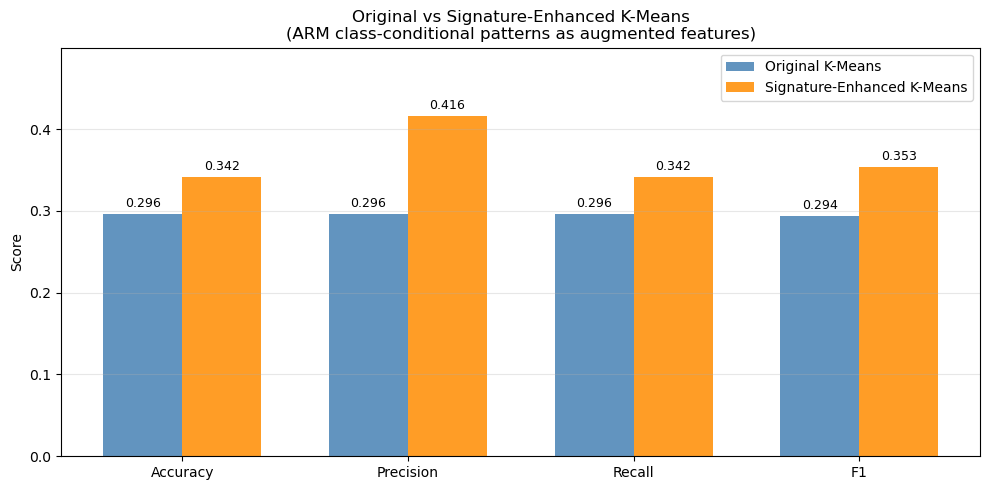

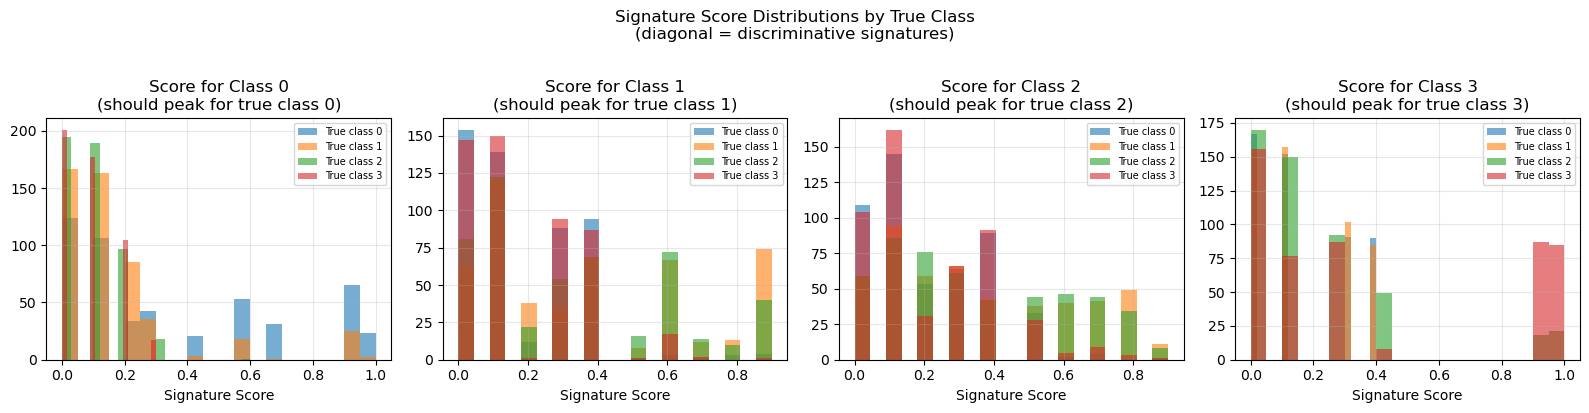

d:\Workspace\Applications\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\Workspace\Applications\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


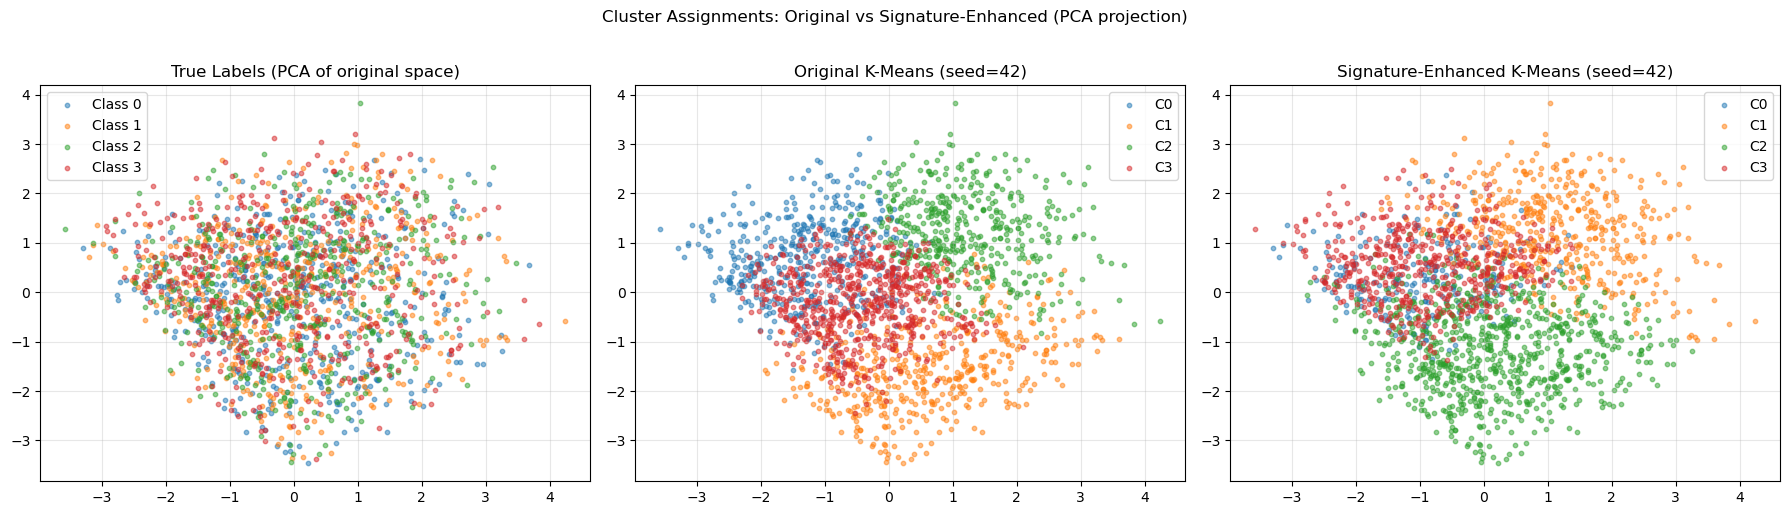

In [14]:
# ── 8. Visualization ──────────────────────────────────────────────────────────
 
from sklearn.decomposition import PCA
 
# Average metric comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics)); w = 0.35
avg_orig = summary.loc['Original K-Means', metrics].values
avg_enh  = summary.loc['Signature-Enhanced K-Means', metrics].values
 
b1 = ax.bar(x - w/2, avg_orig, w, label='Original K-Means',
            color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, avg_enh,  w, label='Signature-Enhanced K-Means',
            color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Original vs Signature-Enhanced K-Means\n'
             '(ARM class-conditional patterns as augmented features)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, min(1.0, max(avg_orig.max(), avg_enh.max()) * 1.2))
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
 
# Signature score distribution by true class
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for c in CLASSES:
    for true_c in CLASSES:
        axes[c].hist(sig_features[y == true_c, c],
                     bins=20, alpha=0.6, label=f'True class {true_c}')
    axes[c].set_title(f'Score for Class {c}\n(should peak for true class {c})')
    axes[c].set_xlabel('Signature Score')
    axes[c].legend(fontsize=7)
    axes[c].grid(alpha=0.3)
plt.suptitle('Signature Score Distributions by True Class\n'
             '(diagonal = discriminative signatures)', y=1.02)
plt.tight_layout(); plt.show()
 
# PCA cluster visualization
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# True labels
for c in CLASSES:
    axes[0].scatter(X_pca[y==c, 0], X_pca[y==c, 1],
                    s=10, alpha=0.5, label=f'Class {c}')
axes[0].set_title('True Labels (PCA of original space)')
axes[0].legend(); axes[0].grid(alpha=0.3)
 
# Original K-Means
p_orig = KMeans(n_clusters=N_CLUSTERS, random_state=42,
                n_init=10).fit_predict(X_scaled)
for k in range(N_CLUSTERS):
    axes[1].scatter(X_pca[p_orig==k, 0], X_pca[p_orig==k, 1],
                    s=10, alpha=0.5, label=f'C{k}')
axes[1].set_title('Original K-Means (seed=42)')
axes[1].legend(); axes[1].grid(alpha=0.3)
 
# Signature-Enhanced K-Means
p_enh = KMeans(n_clusters=N_CLUSTERS, random_state=42,
               n_init=20).fit_predict(X_augmented)
for k in range(N_CLUSTERS):
    axes[2].scatter(X_pca[p_enh==k, 0], X_pca[p_enh==k, 1],
                    s=10, alpha=0.5, label=f'C{k}')
axes[2].set_title('Signature-Enhanced K-Means (seed=42)')
axes[2].legend(); axes[2].grid(alpha=0.3)
 
plt.suptitle('Cluster Assignments: Original vs Signature-Enhanced (PCA projection)',
             y=1.02)
plt.tight_layout(); plt.show()